# Análisis Descriptivo y Modelado — Sector Gastronómico Peruano
### Databricks Serverless · Spark SQL · **scikit-learn** · GeoPandas
> MLlib ha sido reemplazado por **scikit-learn** (KMeans + TfidfVectorizer/LDA).  
> Todo el ML corre en pandas/Python puro sobre los subconjuntos agregados que ya se traen a pandas con `.toPandas()`.  
> Los mapas usan **geopandas** (mapas coropléticos) y **folium** (mapas interactivos).

**Prerequisito:** Ejecutar primero `Medallon_Final_Corregido.ipynb`.


In [0]:
%pip install folium scikit-learn nltk geopandas "pandas>=1.0.5,<3" --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
# Reconexión Spark tras reinicio de kernel
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
#sk learn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
# Geo
import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

CATALOGO              = 'proyecto_bda'
SCHEMA                = 'bda_schema'
TBL_GOLD_FINAL        = f'{CATALOGO}.{SCHEMA}.gold_reviews_final'
TBL_GOLD_STATS_CAT    = f'{CATALOGO}.{SCHEMA}.gold_stats_categoria'
TBL_GOLD_FEAT_USUARIO = f'{CATALOGO}.{SCHEMA}.gold_features_usuario'
VOLUMEN_BASE          = f'/Volumes/{CATALOGO}/{SCHEMA}/bda_volumen'
GEOJSON_DEP  = f'{VOLUMEN_BASE}/peru_departamental_simple.geojson'
GEOJSON_PROV = f'{VOLUMEN_BASE}/peru_provincial_simple.geojson'
GEOJSON_DIST = f'{VOLUMEN_BASE}/peru_distrital_simple.geojson'

spark.sql(f'USE CATALOG {CATALOGO}')
spark.sql(f'USE SCHEMA {SCHEMA}')


DataFrame[]

Carga de Datos desde Capa Gold

In [0]:
sdf = spark.table(TBL_GOLD_FINAL)
sdf.createOrReplaceTempView('gold')

print(f'Registros en Gold : {sdf.count():,}')
print(f'Columnas          : {sdf.columns}')
sdf.printSchema()


Registros en Gold : 1,294,709
Columnas          : ['place_id', 'id_review', 'caption', 'relative_date', 'review_date', 'retrieval_date', 'rating', 'username', 'n_review_user', 'n_photo_user', 'url_user', 'url_source', 'text_len', 'word_count', 'caption_clean', 'rating_category', 'year', 'month', 'day_of_week', 'name', 'category', 'address', 'phoneNumber', 'coor', 'avg_rating', 'url', 'url_place', 'latitude', 'longitude', 'sentimiento']
root
 |-- place_id: string (nullable = true)
 |-- id_review: string (nullable = true)
 |-- caption: string (nullable = true)
 |-- relative_date: string (nullable = true)
 |-- review_date: timestamp (nullable = true)
 |-- retrieval_date: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- username: string (nullable = true)
 |-- n_review_user: string (nullable = true)
 |-- n_photo_user: string (nullable = true)
 |-- url_user: string (nullable = true)
 |-- url_source: string (nullable = true)
 |-- text_len: integer (nullable = true)
 |-- wor

##Análisis de Engagement Temporal
Agregaciones vía Spark SQL — el resultado pequeño pasa a pandas para graficar.


/databricks/python/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/databricks/python/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/databricks/python/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/databricks/python/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

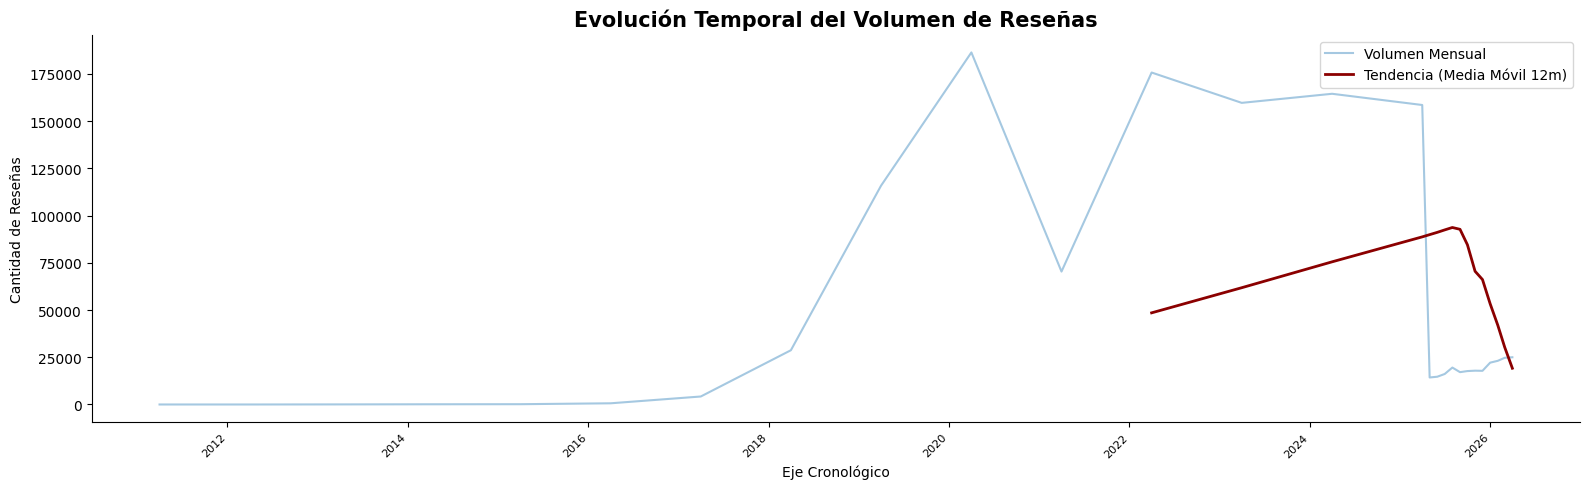

In [0]:
# Volumen mensual
temporal = spark.sql("""
    SELECT
        DATE_FORMAT(review_date, 'yyyy-MM') AS year_month,
        COUNT(*)                            AS total_reviews
    FROM gold
    WHERE review_date IS NOT NULL
    GROUP BY year_month
    ORDER BY year_month
""").toPandas()

temporal['year_month_dt'] = pd.to_datetime(temporal['year_month'])
temporal['rolling_avg']   = temporal['total_reviews'].rolling(window=12).mean() #smoothing

plt.figure(figsize=(16, 5))
sns.lineplot(data=temporal, x='year_month_dt', y='total_reviews',alpha=0.4, label='Volumen Mensual')
sns.lineplot(data=temporal, x='year_month_dt', y='rolling_avg',color='darkred', linewidth=2, label='Tendencia (Media Móvil 12m)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Evolución Temporal del Volumen de Reseñas', fontsize=15, fontweight='bold')
plt.xlabel('Eje Cronológico'); plt.ylabel('Cantidad de Reseñas')
plt.legend()
sns.despine()
plt.tight_layout(); plt.show()


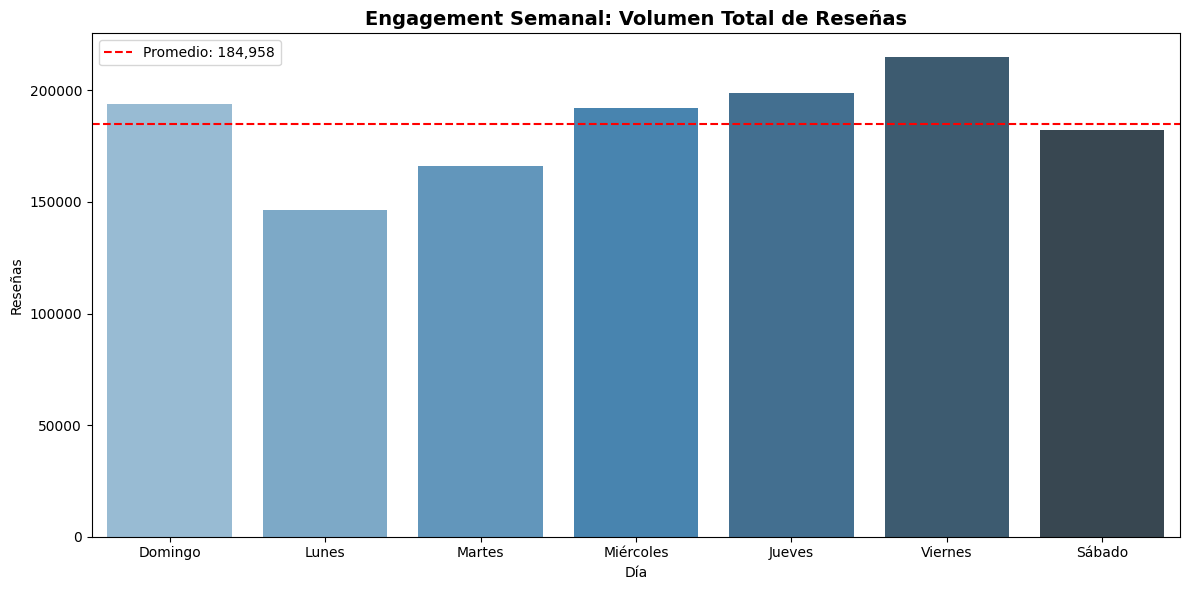

In [0]:
#  Distribución por día de la semana 
day_map = {1:'Domingo', 2:'Lunes', 3:'Martes', 4:'Miércoles',5:'Jueves',  6:'Viernes', 7:'Sábado'}

day_dist = spark.sql("""
    SELECT day_of_week, COUNT(*) AS total
    FROM gold
    GROUP BY day_of_week
    ORDER BY day_of_week
""").toPandas()
day_dist['dia'] = day_dist['day_of_week'].map(day_map)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=day_dist, x='dia', y='total', palette='Blues_d')
ax.legend_.remove() if ax.legend_ else None
plt.axhline(day_dist['total'].mean(), color='red', linestyle='--',label=f'Promedio: {int(day_dist["total"].mean()):,}')
plt.title('Engagement Semanal: Volumen Total de Reseñas', fontsize=14, fontweight='bold')
plt.xlabel('Día'); plt.ylabel('Reseñas')
plt.legend()
plt.tight_layout(); plt.show()

##Análisis Geográfico Regional
Spark SQL agrega coordenadas. Se generan mapas con GeoPandas (departamento, provincia, Lima distrital)


In [0]:
#  Agregación por local vía Spark SQL
geo_agg = spark.sql("""
    SELECT
        place_id, name, category, latitude, longitude,
        COUNT(id_review)      AS total_reviews,
        ROUND(AVG(rating), 2) AS avg_rating
    FROM gold
    WHERE latitude IS NOT NULL AND longitude IS NOT NULL
    GROUP BY place_id, name, category, latitude, longitude
""").toPandas()

print(f'Locales con coordenadas: {len(geo_agg):,}')


Locales con coordenadas: 18,360


In [0]:
# GeoDataFrame de reseñas
df_geo = spark.sql("""
    SELECT id_review, place_id, rating, review_date, latitude, longitude, word_count
    FROM gold
    WHERE latitude is not null and longitude is not null
""").toPandas()

try:
    peru_dep  = gpd.read_file(GEOJSON_DEP)
    peru_prov = gpd.read_file(GEOJSON_PROV)
    peru_dist = gpd.read_file(GEOJSON_DIST)

    gdf_reviews = gpd.GeoDataFrame(df_geo,geometry=gpd.points_from_xy(df_geo.longitude, df_geo.latitude),crs='EPSG:4326')
    gdf_dep = gpd.sjoin(gdf_reviews, peru_dep[['NOMBDEP', 'geometry']], predicate='within')
    print(f'GeoDataFrame listo: {len(gdf_dep):,} reseñas geolocalizadas')
except FileNotFoundError as e:
    print(f'GeoJSON no encontrado en el volumen: {e}')


GeoDataFrame listo: 1,226,819 reseñas geolocalizadas


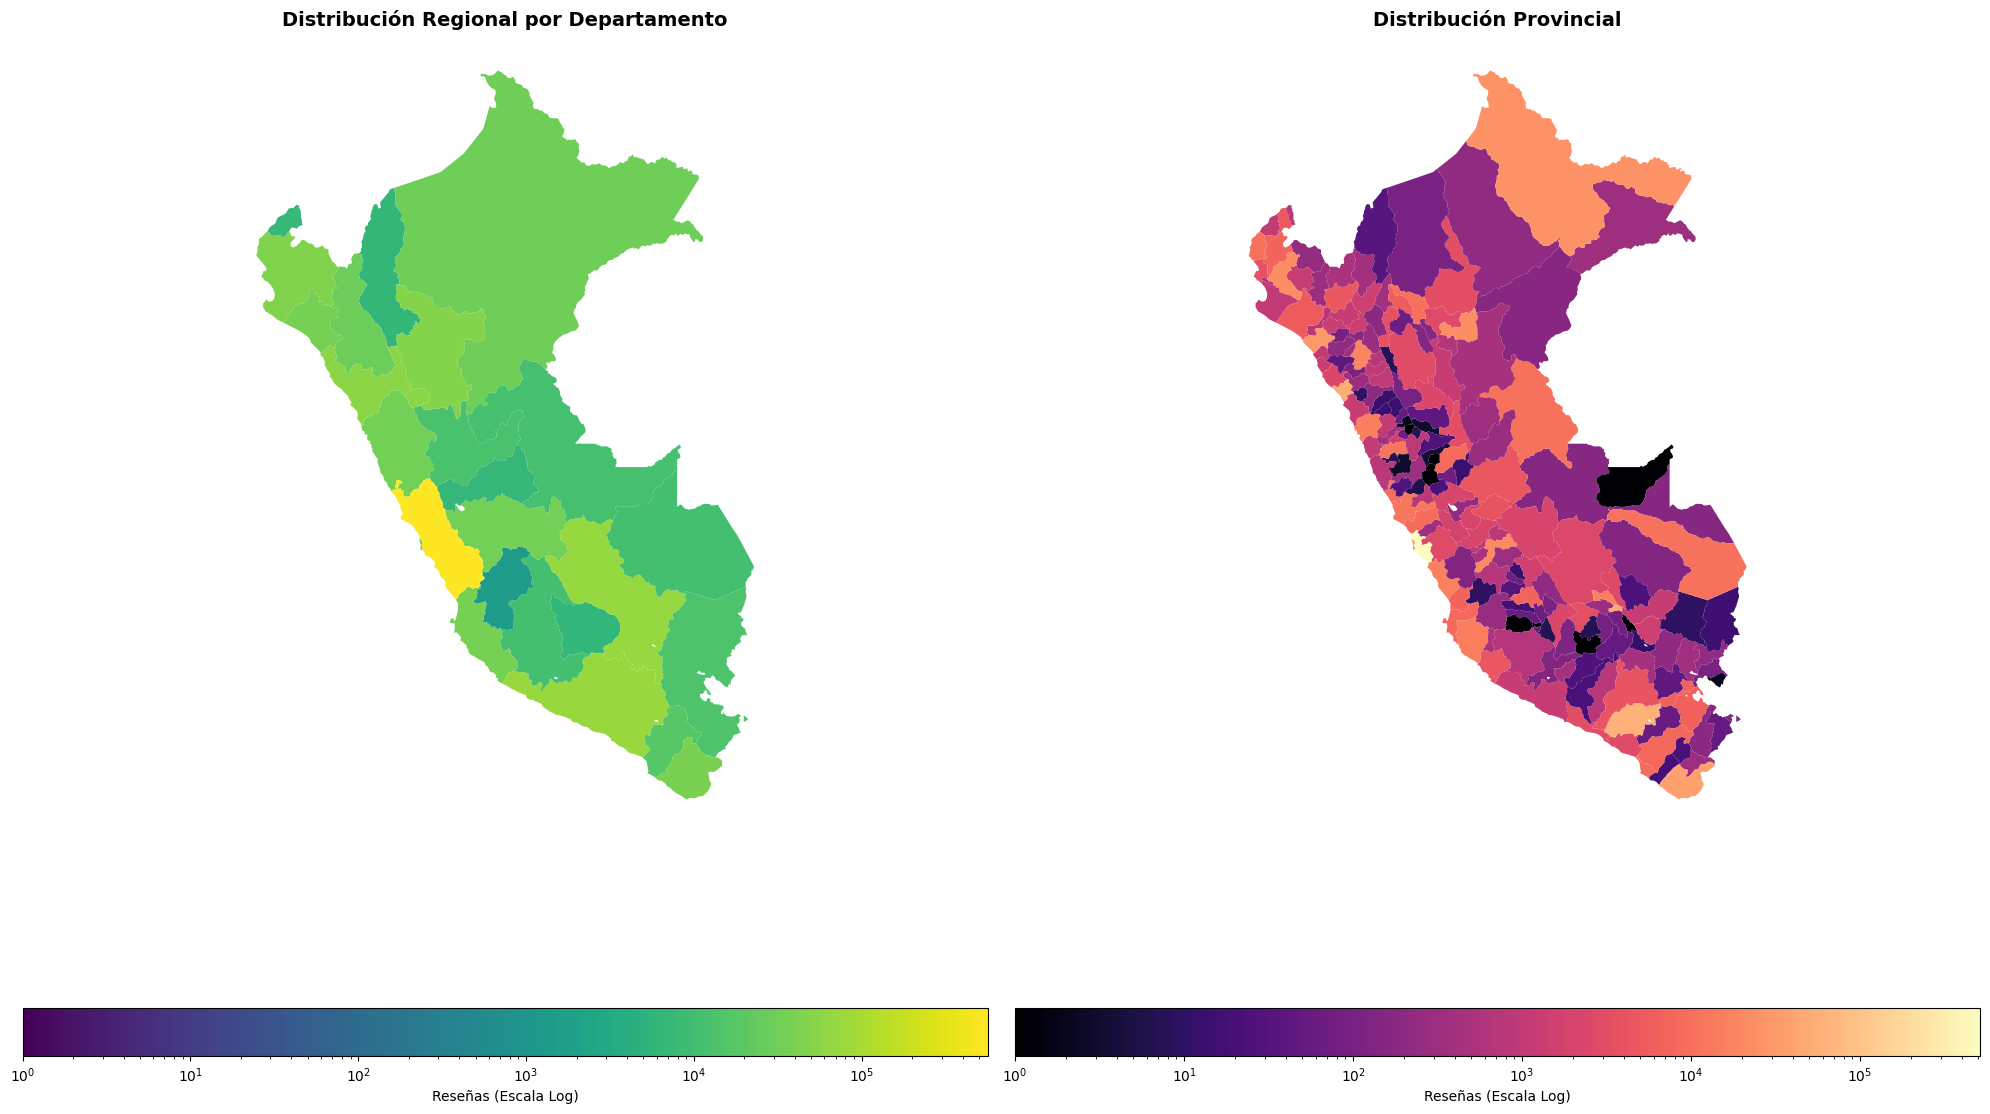

In [0]:
# Mapas coropléticos - Departamento y Provincia
try:
    dep_counts = gdf_dep.groupby('NOMBDEP').size().reset_index(name='review_count')
    dep_map    = peru_dep.merge(dep_counts, on='NOMBDEP', how='left').fillna({'review_count': 1})

    gdf_prov    = gpd.sjoin(gdf_reviews, peru_prov[['NOMBPROV', 'geometry']], predicate='within')
    prov_counts = gdf_prov.groupby('NOMBPROV').size().reset_index(name='review_count')
    prov_map    = peru_prov.merge(prov_counts, on='NOMBPROV', how='left').fillna({'review_count': 1})

    fig, ax = plt.subplots(1, 2, figsize=(20, 12))

    dep_map.plot(column='review_count', ax=ax[0], legend=True, cmap='viridis',
                 norm=colors.LogNorm(vmin=1, vmax=dep_map['review_count'].max()),
                 legend_kwds={'label': 'Reseñas (Escala Log)', 'orientation': 'horizontal'})
    ax[0].set_title('Distribución Regional por Departamento', fontsize=14, fontweight='bold')
    ax[0].axis('off')

    prov_map.plot(column='review_count', ax=ax[1], legend=True, cmap='magma',
                  norm=colors.LogNorm(vmin=1, vmax=prov_map['review_count'].max()),
                  legend_kwds={'label': 'Reseñas (Escala Log)', 'orientation': 'horizontal'})
    ax[1].set_title('Distribución Provincial', fontsize=14, fontweight='bold')
    ax[1].axis('off')

    plt.tight_layout(); plt.show()
except NameError:
    print('Ejecuta primero la celda de carga de GeoDataFrame')


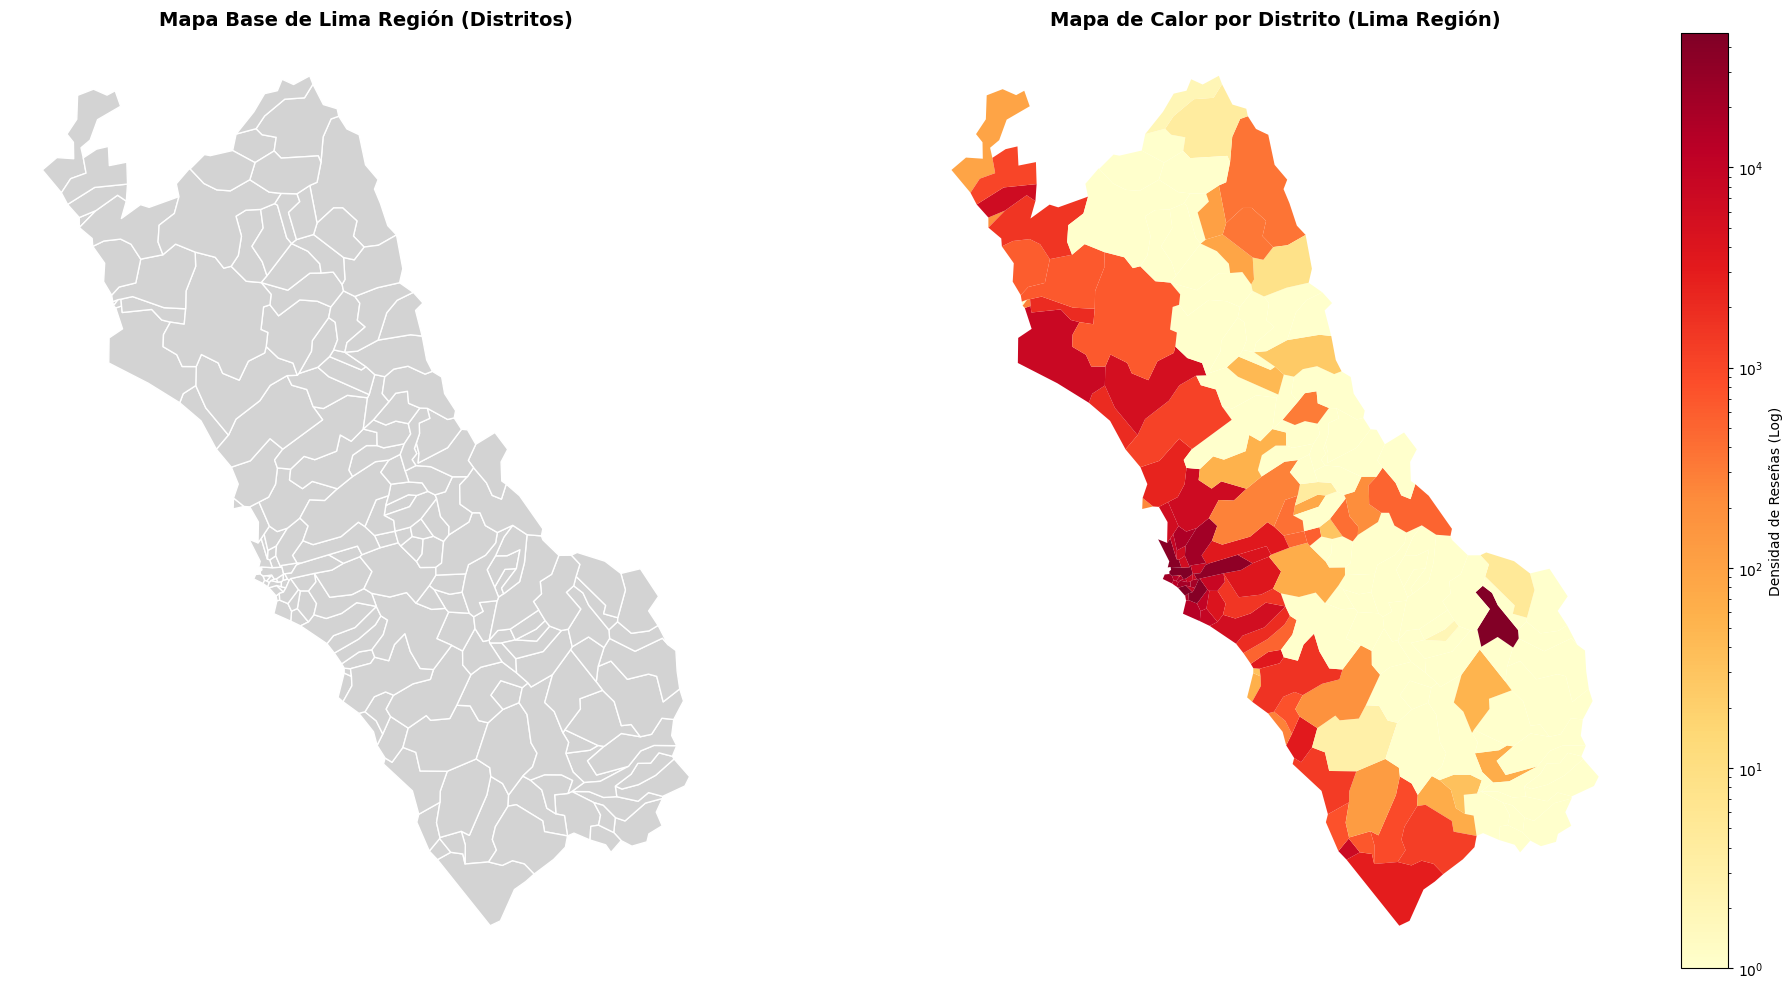

In [0]:
# Lima Región - mapa base y mapa de calor distrital
try:
    lima_distritos = peru_dist[peru_dist['NOMBDEP'] == 'LIMA'].copy()
    gdf_lima       = gpd.sjoin(gdf_reviews, lima_distritos[['NOMBDIST', 'geometry']], predicate='within')
    dist_counts    = gdf_lima.groupby('NOMBDIST').size().reset_index(name='review_count')
    lima_map_data  = lima_distritos.merge(dist_counts, on='NOMBDIST', how='left').fillna({'review_count': 1})

    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    lima_distritos.plot(ax=ax[0], color='lightgrey', edgecolor='white')
    ax[0].set_title('Mapa Base de Lima Región (Distritos)', fontsize=14, fontweight='bold')
    ax[0].axis('off')

    lima_map_data.plot(column='review_count', ax=ax[1], legend=True, cmap='YlOrRd',
                       norm=colors.LogNorm(vmin=1, vmax=lima_map_data['review_count'].max()),
                       legend_kwds={'label': 'Densidad de Reseñas (Log)', 'orientation': 'vertical'})
    ax[1].set_title('Mapa de Calor por Distrito (Lima Región)', fontsize=14, fontweight='bold')
    ax[1].axis('off')
    plt.tight_layout(); plt.show()
except NameError:
    print('Ejecuta primero la celda de carga de GeoDataFrame.')


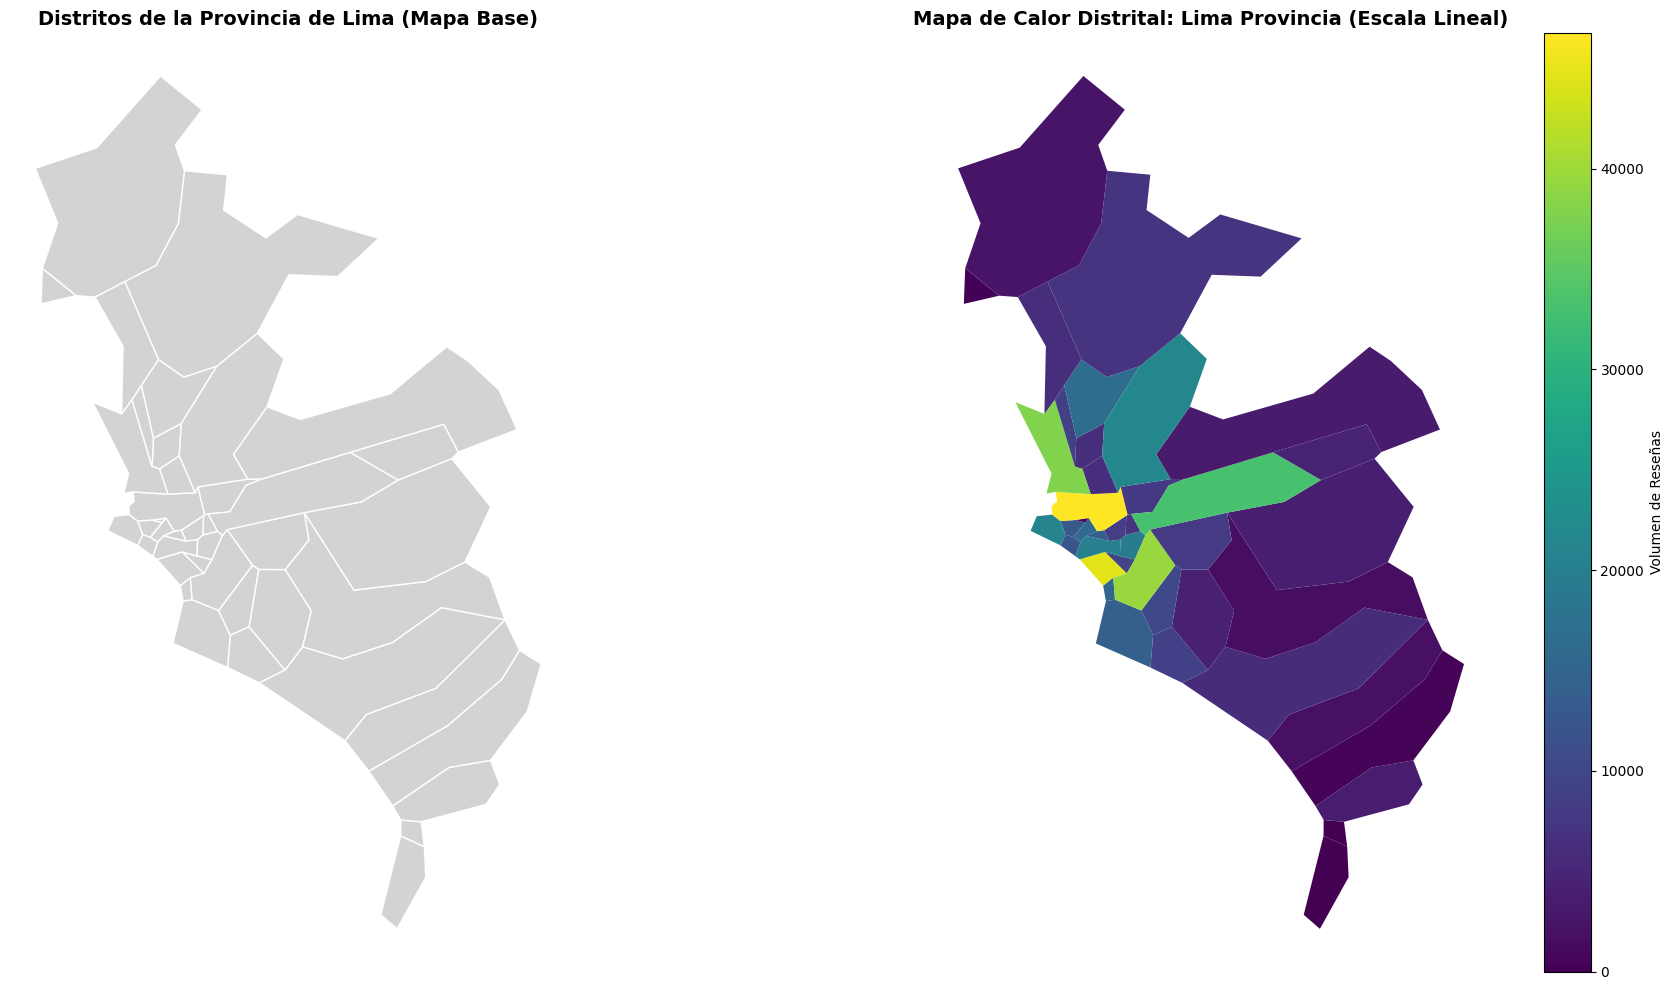

In [0]:
# Lima Provincia - escala lineal viridis
try:
    lima_prov_dist = peru_dist[peru_dist['NOMBPROV'] == 'LIMA'].copy()
    gdf_lima_prov  = gpd.sjoin(gdf_reviews, lima_prov_dist[['NOMBDIST', 'geometry']], predicate='within')
    dist_prov_counts = gdf_lima_prov.groupby('NOMBDIST').size().reset_index(name='review_count')
    lima_prov_data   = lima_prov_dist.merge(dist_prov_counts, on='NOMBDIST', how='left').fillna({'review_count': 0})

    fig, ax = plt.subplots(1, 2, figsize=(20, 10))

    lima_prov_dist.plot(ax=ax[0], color='lightgrey', edgecolor='white')
    ax[0].set_title('Distritos de la Provincia de Lima (Mapa Base)', fontsize=14, fontweight='bold')
    ax[0].axis('off')

    lima_prov_data.plot(column='review_count', ax=ax[1], legend=True, cmap='viridis',
                        legend_kwds={'label': 'Volumen de Reseñas', 'orientation': 'vertical'})
    ax[1].set_title('Mapa de Calor Distrital: Lima Provincia (Escala Lineal)', fontsize=14, fontweight='bold')
    ax[1].axis('off')

    plt.tight_layout(); plt.show()
except NameError:
    print('Ejecuta primero la celda de carga de GeoDataFrame.')


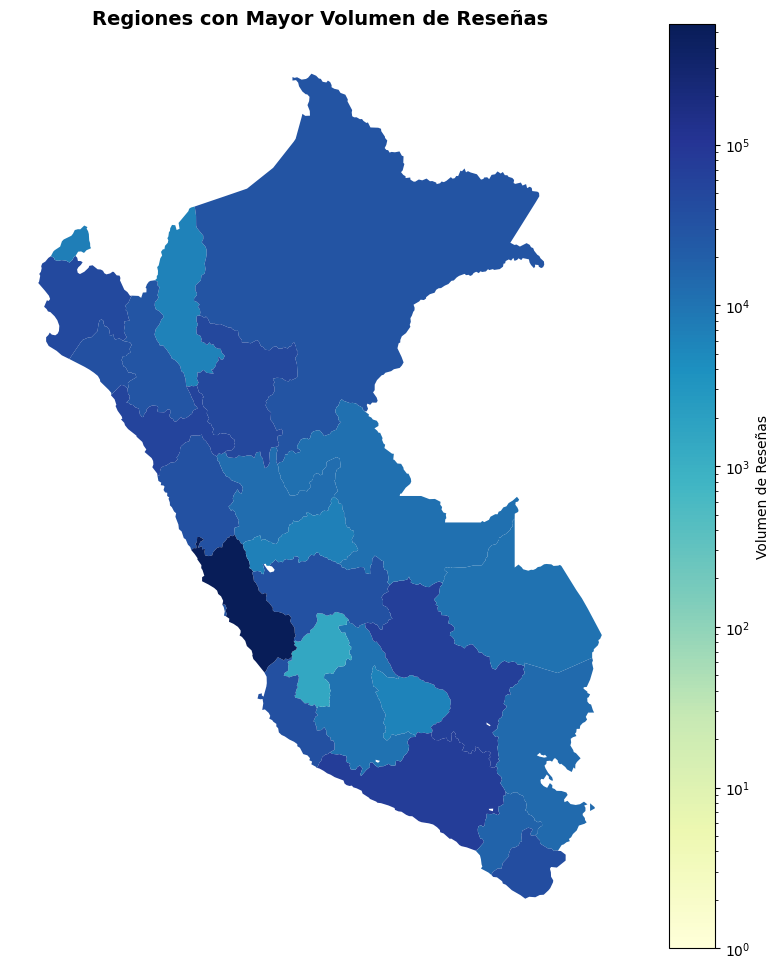

In [0]:
# Engagement textual por departamento
try:
    dep_stats = gdf_dep.groupby('NOMBDEP').agg(
        promedio_palabras=('review_date', 'count'),
        total_reviews=('id_review', 'count')
    ).reset_index()

    # Si el df tiene word_count, usar eso
    if 'word_count' in gdf_dep.columns:
        dep_stats = gdf_dep.groupby('NOMBDEP').agg(
            promedio_palabras=('word_count', 'mean'),
            rating_promedio=('rating', 'mean'),
            total_reviews=('id_review', 'count')
        ).reset_index()

    map_eng = peru_dep.merge(dep_stats, on='NOMBDEP', how='left')

    fig, ax = plt.subplots(1, 1, figsize=(10, 12))
    map_eng.plot(column='total_reviews', ax=ax, legend=True, cmap='YlGnBu',
                 norm=colors.LogNorm(vmin=1, vmax=map_eng['total_reviews'].max()),
                 legend_kwds={'label': 'Volumen de Reseñas'})
    ax.set_title('Regiones con Mayor Volumen de Reseñas', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.show()
except NameError:
    print('Ejecuta primero la celda de carga de GeoDataFrame')


In [0]:
#Top 10 distritos y restaurantes
try:
    map_completo = gpd.read_file(GEOJSON_DIST)
    gdf_completo = gpd.sjoin(gdf_reviews, map_completo[['NOMBDEP', 'NOMBPROV', 'NOMBDIST', 'geometry']], predicate='within')

    top_distritos = (
        gdf_completo.groupby(['NOMBDEP', 'NOMBPROV', 'NOMBDIST'])
        .size().reset_index(name='total_reviews')
        .sort_values('total_reviews', ascending=False).head(10)
    )
    print('Top 10 Distritos con más reseñas en Perú:')
    display(top_distritos)
except NameError:
    print('Ejecuta primero la celda de carga de GeoDataFrame')


Top 10 Distritos con más reseñas en Perú:


NOMBDEP,NOMBPROV,NOMBDIST,total_reviews
LIMA,LIMA,LIMA,46751
LIMA,LIMA,MIRAFLORES,44721
LIMA,LIMA,SANTIAGO DE SURCO,39603
LIMA,LIMA,SAN MARTIN DE PORRES,37974
CUSCO,CUSCO,CUSCO,34969
LA LIBERTAD,TRUJILLO,TRUJILLO,34142
LIMA,LIMA,ATE,33141
TACNA,TACNA,TACNA,29116
LIMA,LIMA,SAN JUAN DE LURIGANCHO,21655
AREQUIPA,AREQUIPA,AREQUIPA,21274


In [0]:
# Resumen SQL por departamento
spark.sql("""
    SELECT
        CASE
            WHEN address LIKE '%Lima%'       THEN 'Lima'
            WHEN address LIKE '%Cusco%'      THEN 'Cusco'
            WHEN address LIKE '%Arequipa%'   THEN 'Arequipa'
            WHEN address LIKE '%Trujillo%'   THEN 'La Libertad'
            WHEN address LIKE '%Piura%'      THEN 'Piura'
            WHEN address LIKE '%Iquitos%'    THEN 'Loreto'
            WHEN address LIKE '%Chiclayo%'   THEN 'Lambayeque'
            WHEN address LIKE '%Huancayo%'   THEN 'Junín'
            WHEN address LIKE '%Puno%'       THEN 'Puno'
            WHEN address LIKE '%Tacna%'      THEN 'Tacna'
            ELSE 'Otros'
        END AS departamento,
        COUNT(id_review) AS total_resenas,
        ROUND(AVG(rating), 2) AS rating_promedio,
        COUNT(DISTINCT place_id) AS total_locales
    FROM gold
    GROUP BY departamento
    ORDER BY total_resenas DESC
""").show(truncate=False)


+------------+-------------+---------------+-------------+
|departamento|total_resenas|rating_promedio|total_locales|
+------------+-------------+---------------+-------------+
|Otros       |941332       |4.17           |14472        |
|Lima        |109741       |4.13           |1040         |
|Cusco       |44649        |4.26           |421          |
|Tacna       |39833        |4.11           |535          |
|Arequipa    |36114        |4.08           |414          |
|La Libertad |32494        |4.21           |271          |
|Loreto      |25527        |4.17           |375          |
|Lambayeque  |22399        |4.25           |225          |
|Piura       |20986        |4.2            |268          |
|Junín       |15652        |3.86           |244          |
|Puno        |5982         |3.92           |96           |
+------------+-------------+---------------+-------------+



In [0]:
# Top 10 Restaurantes (Las cadenas se cuentan como uno)
spark.sql("""
    SELECT
        name AS Restaurante,
        category AS Categoria,
        COUNT(id_review) AS Total_Resenas,
        ROUND(AVG(rating), 2) AS Rating_Promedio
    FROM gold
    WHERE latitude IS NOT NULL
    GROUP BY name, category
    ORDER BY Total_Resenas DESC
    LIMIT 10
""").show(truncate=False)


+------------------------------+----------------------------------+-------------+---------------+
|Restaurante                   |Categoria                         |Total_Resenas|Rating_Promedio|
+------------------------------+----------------------------------+-------------+---------------+
|KFC                           |Restaurante de comida rápida      |7923         |3.85           |
|Bembos                        |Restaurante de comida rápida      |1903         |3.96           |
|McDonald's                    |Restaurante de comida rápida      |1703         |3.87           |
|Grido helado                  |Heladería                         |1337         |4.61           |
|Roky's                        |Restaurante especializado en pollo|1316         |3.96           |
|Corralito - Pollos y Parrillas|Pollería                          |1220         |4.14           |
|Corralito                     |Restaurante especializado en pollo|1052         |4.18           |
|Little Caesars Pizz

##Análisis por Categoría de Restaurante

In [0]:
display(spark.table(TBL_GOLD_STATS_CAT).orderBy(F.desc('total_resenas')).limit(9))

category,total_resenas,rating_promedio,rating_desviacion,resenas_positivas,resenas_negativas,promedio_palabras,total_locales,porcentaje_aprobacion
Restaurante,669389,4.12,1.2,515271,74654,7.7,8370,76.98
Restaurante peruano,92924,4.23,1.16,74496,9136,9.4,792,80.17
Pizzería,83091,4.23,1.16,66778,8024,7.9,1094,80.37
Cafetería,56487,4.34,1.08,47344,4512,10.2,830,83.81
Restaurante especializado en pollo,47412,4.06,1.25,35713,5968,7.3,647,75.32
Restaurante de comida rápida,44694,4.08,1.26,33943,5622,6.9,1018,75.95
Restaurante chino,43510,3.97,1.25,31496,5822,7.1,419,72.39
Panadería,33075,4.21,1.13,26245,2961,7.0,940,79.35
Heladería,29865,4.37,1.07,25178,2251,8.0,801,84.31


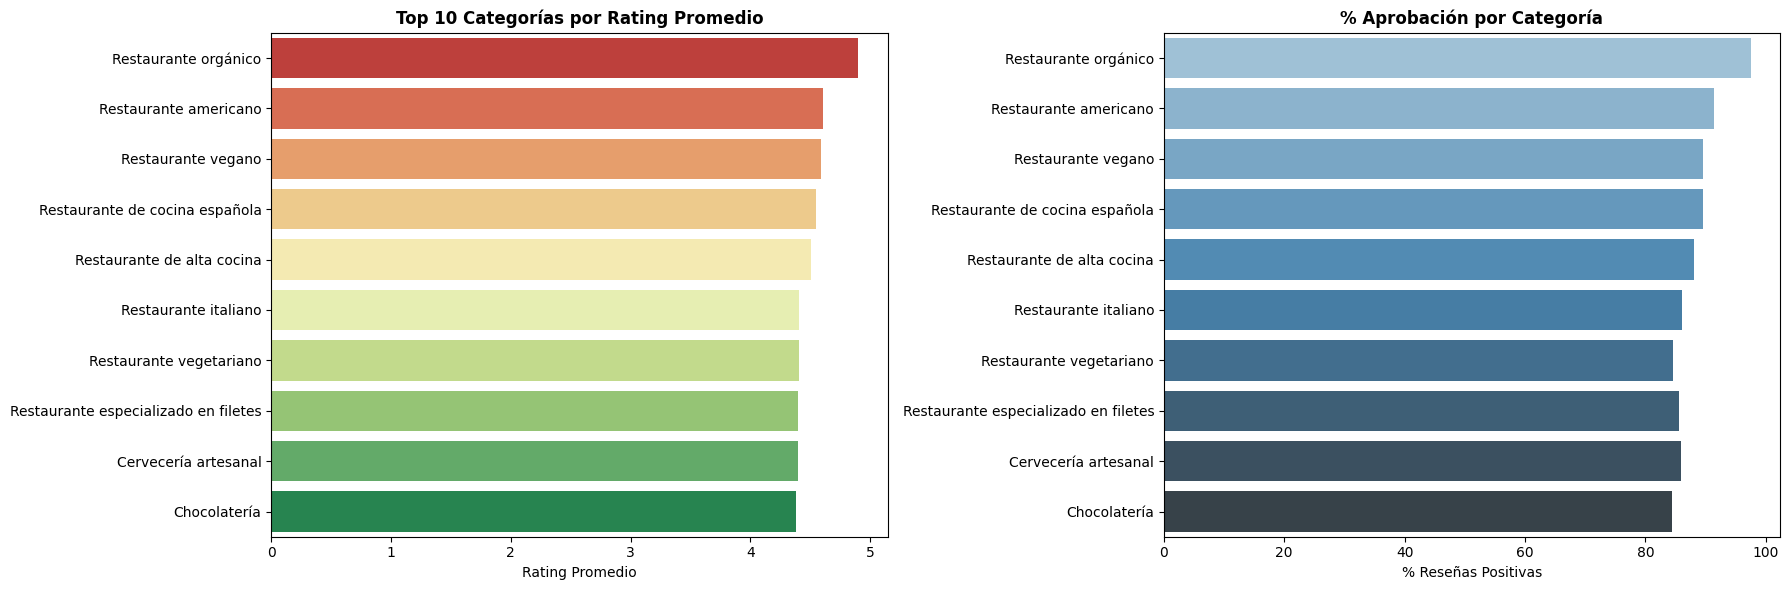

In [0]:
stats_pd = spark.table(TBL_GOLD_STATS_CAT).filter(F.col('total_resenas') > 500).orderBy(F.desc('rating_promedio')).limit(10).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ax0 = sns.barplot(data=stats_pd, y='category', x='rating_promedio',palette='RdYlGn', ax=axes[0])
if ax0.get_legend(): ax0.get_legend().remove()
axes[0].set_title('Top 10 Categorías por Rating Promedio', fontweight='bold')
axes[0].set_xlabel('Rating Promedio'); axes[0].set_ylabel('')

ax1 = sns.barplot(data=stats_pd, y='category', x='porcentaje_aprobacion',
                  palette='Blues_d', ax=axes[1])
if ax1.get_legend(): ax1.get_legend().remove()
axes[1].set_title('% Aprobación por Categoría', fontweight='bold')
axes[1].set_xlabel('% Reseñas Positivas'); axes[1].set_ylabel('')

plt.tight_layout(); plt.show()


##Segmentación de Usuarios - KMeans con scikit-learn
`gold_features_usuario` se trae a pandas con `.toPandas()` (es un agregado pequeño)


In [0]:
# Cargar features desde Gold
sdf_feat = spark.table(TBL_GOLD_FEAT_USUARIO).fillna(0)
print(f'Usuarios para clustering: {sdf_feat.count():,}')

# Traer a pandas - es el subconjunto de features ya agregadas (1 fila por usuario)
user_features = sdf_feat.toPandas()
print(user_features.head())
print(user_features.dtypes)


Usuarios para clustering: 711,324
               username  review_count  ...  log_review_count  log_avg_word_count
0     Jesus Garcia Luna             1  ...            0.6931              0.6931
1         Zuleika Gomez             1  ...            0.6931              2.9444
2  Fernando Paiva Pingo             1  ...            0.6931              0.6931
3      Alexandra Chavez             2  ...            1.0986              0.6931
4      Milagros Segovia             1  ...            0.6931              0.6931

[5 rows x 7 columns]
username               object
review_count            int64
avg_rating            float64
std_rating            float64
avg_word_count        float64
log_review_count      float64
log_avg_word_count    float64
dtype: object


In [0]:
# Preprocesamiento: escalado con sklearn
feature_cols = ['log_review_count', 'avg_rating', 'std_rating', 'log_avg_word_count']

X = user_features[feature_cols].values
scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Shape:', X_scaled.shape)


Shape: (711324, 4)


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xfffea834cb80>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

  K=2  silhouette=0.4544


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xfffea834cb80>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

  K=3  silhouette=0.4486


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xfffea8655c60>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

...

  K=5  silhouette=0.4642


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xfffea834cb80>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

  K=6  silhouette=0.4827


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xfffe933dde40>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

  K=7  silhouette=0.498

K óptimo: 7 (silhouette=0.498)


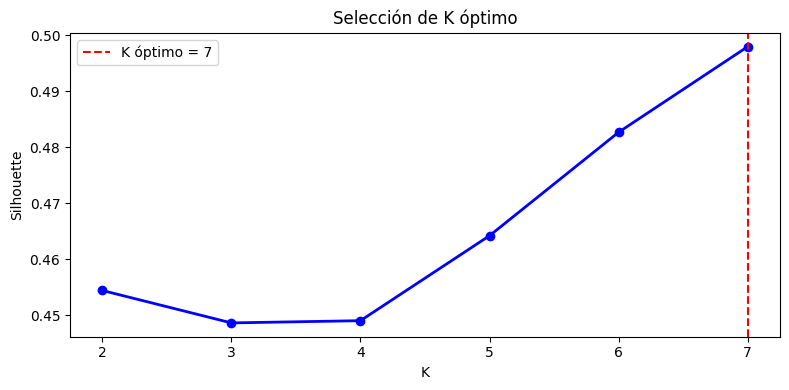

In [0]:
# Búsqueda del K óptimo por Silhouette
# Usamos una muestra de 30 000 para agilizar
rng    = np.random.default_rng(42)
n_sample = min(30_000, len(X_scaled)) # se puede cambiar cuando saquemos más data
idx_sample = rng.choice(len(X_scaled), n_sample, replace=False)
X_sample   = X_scaled[idx_sample]

sil_scores = {}
for k in range(2, 8):
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbls = km.fit_predict(X_sample)
    sil_scores[k] = round(silhouette_score(X_sample, lbls), 4)
    print(f'  K={k}  silhouette={sil_scores[k]}')

k_optimo = max(sil_scores, key=sil_scores.get)
print(f'\nK óptimo: {k_optimo} (silhouette={sil_scores[k_optimo]})')

plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), 'bo-', linewidth=2)
plt.axvline(k_optimo, color='red', linestyle='--', label=f'K óptimo = {k_optimo}')
plt.xlabel('K'); plt.ylabel('Silhouette')
plt.title('Selección de K óptimo'); plt.legend(); plt.tight_layout(); plt.show()


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xfffe8f2b34c0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

cluster,n_usuarios,resenas_promedio,rating_promedio,variabilidad_rating,palabras_promedio
0,291402,1.1,4.76,0.0,1.33
1,158448,1.16,4.84,0.01,17.24
2,30157,10.33,4.1,0.86,9.95
3,43044,1.08,1.57,0.02,29.88
4,71252,1.06,2.22,0.01,1.51
5,77144,3.19,4.36,0.52,4.26
6,39877,2.75,3.32,1.88,10.85


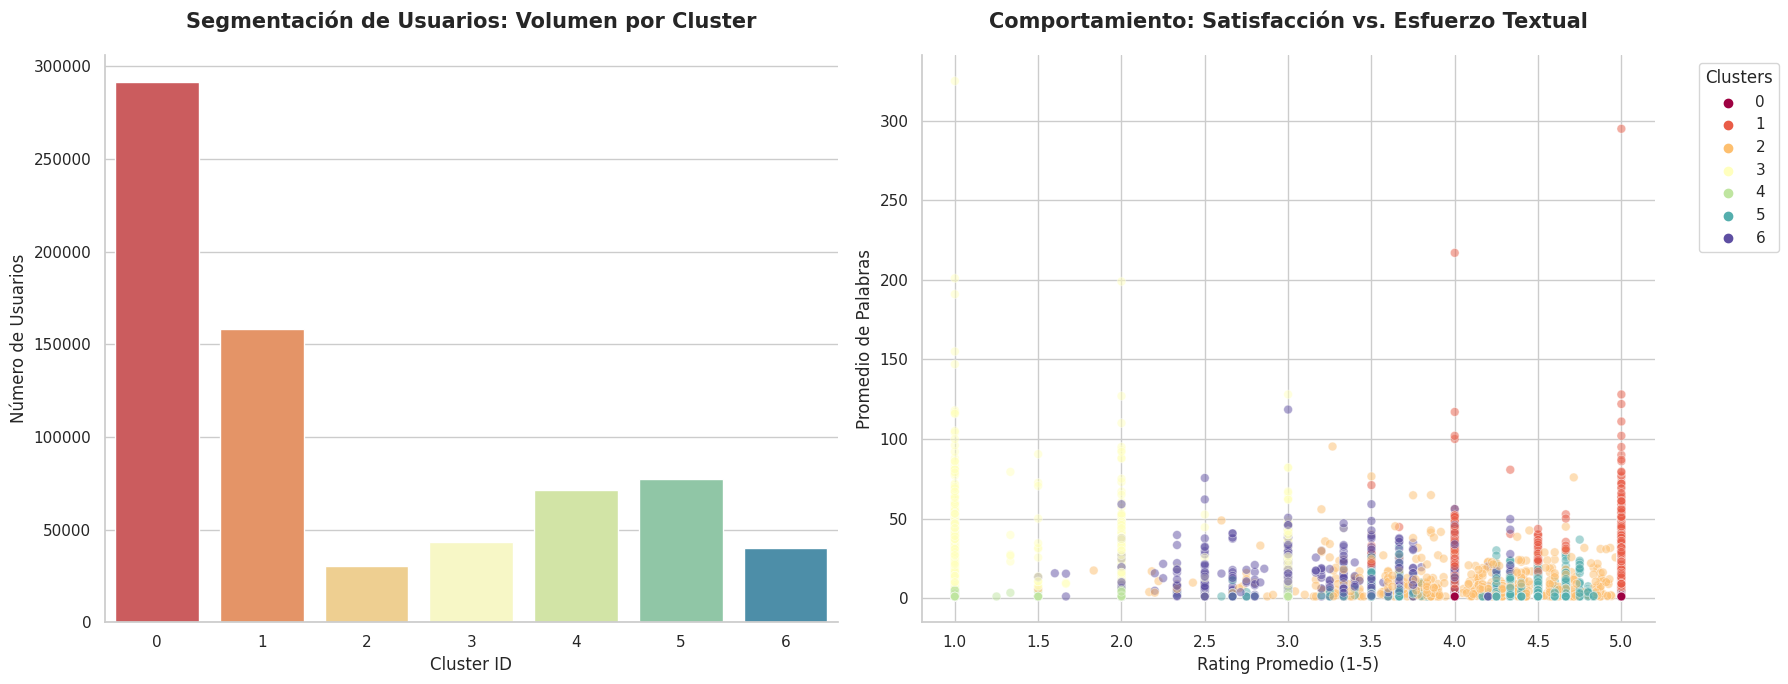

In [0]:
km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
user_features['cluster'] = km_final.fit_predict(X_scaled)

#Resumen por cluster
resumen_pd = (
    user_features[['review_count', 'avg_rating', 'std_rating', 'avg_word_count', 'cluster']]
    .groupby('cluster').mean().round(2).reset_index()
    .rename(columns={
        'review_count':   'resenas_promedio',
        'avg_rating':     'rating_promedio',
        'std_rating':     'variabilidad_rating',
        'avg_word_count': 'palabras_promedio'
    })
)
resumen_pd.insert(1, 'n_usuarios', user_features.groupby('cluster').size().values)
display(resumen_pd)

#Visualización
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.countplot(data=user_features, x='cluster', palette='Spectral', ax=axes[0])
if axes[0].get_legend(): axes[0].get_legend().remove()
axes[0].set_title('Segmentación de Usuarios: Volumen por Cluster', fontsize=15, fontweight='bold', pad=20)
axes[0].set_xlabel('Cluster ID', fontsize=12)
axes[0].set_ylabel('Número de Usuarios', fontsize=12)

scatter_df = user_features.sample(min(15_000, len(user_features)), random_state=42)
sns.scatterplot(data=scatter_df, x='avg_rating', y='avg_word_count',
                hue='cluster', palette='Spectral', alpha=0.5, ax=axes[1], s=40, edgecolor='w')
axes[1].set_title('Comportamiento: Satisfacción vs. Esfuerzo Textual', fontsize=15, fontweight='bold', pad=20)
axes[1].set_xlabel('Rating Promedio (1-5)', fontsize=12)
axes[1].set_ylabel('Promedio de Palabras', fontsize=12)
axes[1].legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

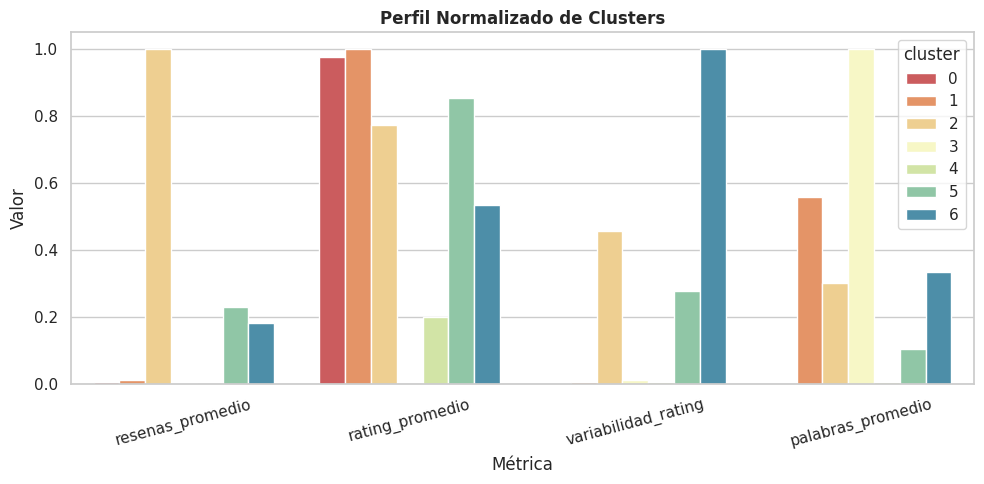

In [0]:
# Perfil normalizado de clusters
metrics = ['resenas_promedio', 'rating_promedio', 'variabilidad_rating', 'palabras_promedio']
resumen_norm = resumen_pd[metrics].copy()
resumen_norm = (resumen_norm - resumen_norm.min()) / (resumen_norm.max() - resumen_norm.min() + 1e-9)
resumen_norm['cluster'] = resumen_pd['cluster'].astype(str)
resumen_melt = resumen_norm.melt(id_vars='cluster', var_name='Métrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=resumen_melt, x='Métrica', y='Valor', hue='cluster', palette='Spectral', ax=ax)
ax.set_title('Perfil Normalizado de Clusters', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

### Interpretación de Clusters OJO

| Cluster | Perfil | Descripción | Acción recomendada |
|---------|--------|-------------|-------------------|
| 0 | **Visitante ocasional neutral** | Pocas reseñas, rating medio, textos cortos | Campañas de reactivación con descuentos |
| 1 | **Crítico detallista** | Rating bajo/variable, textos largos | Escalar quejas a operaciones — señal de alerta temprana |
| 2 | **Embajador activo** | Muchas reseñas, rating alto, textos elaborados | Programa de fidelización / influencer gastronómico |
| 3 | **Evaluador rápido positivo** | Pocas palabras, rating consistentemente alto | Ideal para incentivar reseñas en Google Maps |

> Si nos quedamos con k=7 falta ajustar esto ..................................................


## Modelado de Tópicos - LDA con scikit-learn
`TfidfVectorizer` (o `CountVectorizer`) + `LatentDirichletAllocation` de sklearn.  
El corpus se trae a pandas con `.toPandas()` sobre la muestra NLP.


In [0]:
# Muestra de textos para LDA
from nltk.corpus import stopwords
custom_stops = ['si', 'lugar', 'sitio', 'vez', 'mas', 'más', 'ser', 'hacer','ir', 'muy', 'bien', 'todo', 'nada', 'así', 'aquí']
spanish_stops = list(set(stopwords.words('spanish') + custom_stops))

sdf_nlp = sdf.select('id_review', 'caption_clean', 'sentimiento') \
    .filter(F.col('caption_clean').isNotNull() & (F.length('caption_clean') > 20)) \
    .sample(fraction=0.15, seed=42) #Si se demora demasiado podriamos usar un fraction fijo de 100 000 por ejemplo

df_nlp = sdf_nlp.toPandas()
print(f'Reseñas para LDA: {len(df_nlp):,}')
sample_text = df_nlp['caption_clean'].dropna()


Reseñas para LDA: 77,127


In [0]:
# Vectorización CountVectorizer + LDA
tf_vectorizer = CountVectorizer(
    max_df=0.85,
    min_df=5,
    ngram_range=(1, 2),
    stop_words=spanish_stops
)
tf = tf_vectorizer.fit_transform(sample_text)

lda_model = LatentDirichletAllocation(
    n_components=5,
    max_iter=10,
    learning_method='online',
    learning_offset=50.0,
    random_state=42
)
lda_model.fit(tf)

perplexity_score = lda_model.perplexity(tf)
print(f'Métrica de Validación - Perplejidad del Modelo: {perplexity_score:.2f}\n')

vocab = tf_vectorizer.get_feature_names_out()

print('=' * 55)
for topic_idx, topic in enumerate(lda_model.components_):
    top_idx   = topic.argsort()[:-11:-1]
    top_words = [vocab[i] for i in top_idx]
    print(f'Tópico {topic_idx}: {" | ".join(top_words)}')
print('='*100)


Métrica de Validación - Perplejidad del Modelo: 3274.95

Tópico 0: pollo | rico | papas | recomiendo | sabor | siempre | mejor | bueno | delicioso | brasa
Tópico 1: platos | sabor | calidad | ceviche | bueno | precio | arroz | comida | rico | ricos
Tópico 2: buena | atención | comida | buen | excelente | ambiente | buena atención | servicio | agradable | rica
Tópico 3: comida | deliciosa | mejor | amable | restaurante | excelente | experiencia | servicio | comida deliciosa | pizza
Tópico 4: atención | comida | servicio | solo | mejores | café | mejorar | mala | pedido | mal


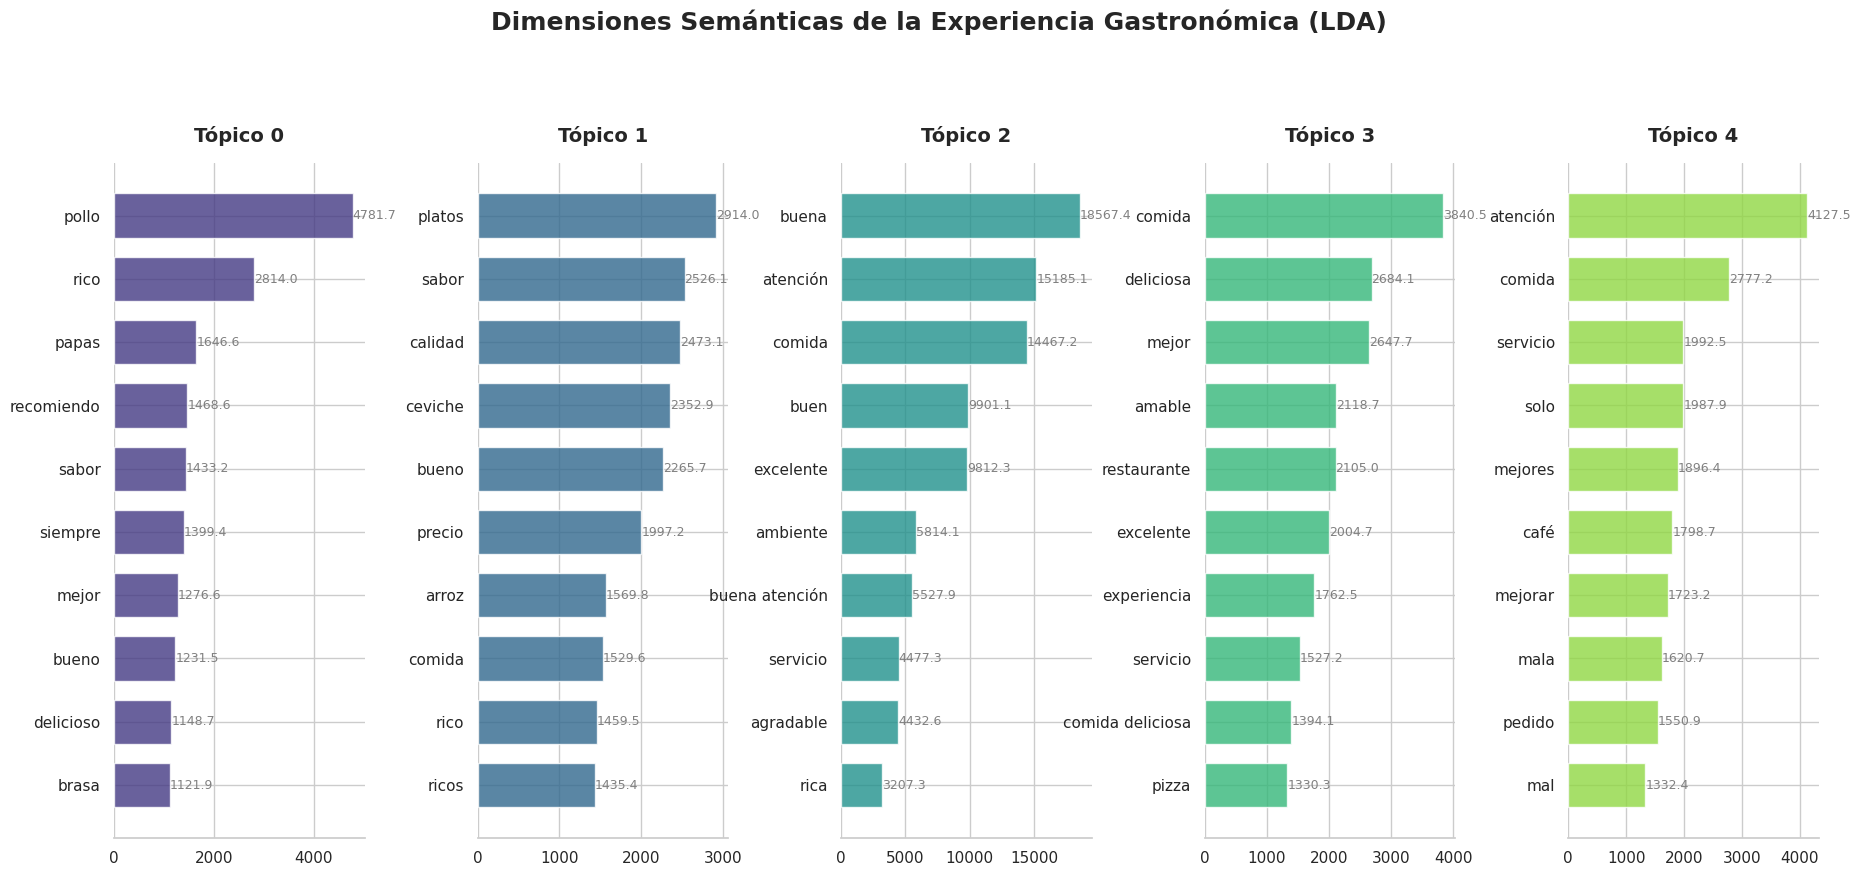

In [0]:
# Visualización de Tópicos
def plot_top_words_pro(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 5, figsize=(22, 9), sharey=False)
    palette = sns.color_palette('viridis', 5)

    for topic_idx, topic in enumerate(model.components_):
        top_ind     = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_ind]
        weights      = topic[top_ind]
        ax   = axes[topic_idx]
        bars = ax.barh(top_features, weights, height=0.7,color=palette[topic_idx], alpha=0.8)
        ax.set_title(f'Tópico {topic_idx}',fontdict={'fontsize': 14, 'fontweight': 'bold'}, pad=15)
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=11)

        for bar in bars:
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height() / 2,f'{width:.1f}', va='center', ha='left', fontsize=9, color='gray')

        for spine in ['top', 'right', 'left']:
            ax.spines[spine].set_visible(False)

    fig.suptitle(title, fontsize=18, fontweight='bold', y=1.02)
    plt.subplots_adjust(top=0.85, bottom=0.1, wspace=0.45)
    plt.show()

plot_top_words_pro(lda_model, vocab, 10,'Dimensiones Semánticas de la Experiencia Gastronómica (LDA)')
